In [1]:
import numpy as np
import pandas as pd

# Set seed for reproducibility
np.random.seed(42)

# Total samples
n_samples = 10000

# Imbalance: 99% class 0, 1% class 1
n_class1 = int(n_samples * 0.01)
n_class0 = n_samples - n_class1

# Feature columns
X1 = np.concatenate([
    np.random.normal(loc=0, scale=1, size=n_class0),   # class 0
    np.random.normal(loc=2, scale=1, size=n_class1)    # class 1
])

X2 = np.concatenate([
    np.random.normal(loc=0, scale=1, size=n_class0),   # class 0
    np.random.normal(loc=2, scale=1, size=n_class1)    # class 1
])

# Target labels
y = np.array([0]*n_class0 + [1]*n_class1)

# Create DataFrame
df = pd.DataFrame({
    'X1': X1,
    'X2': X2,
    'target': y
})

# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Show class distributio


In [ ]:
df

,X1,X2,target
0,2.637882,0.247290,0
1,-1.037066,-0.747222,0
2,-0.349317,2.445770,0
3,0.001619,0.482930,0
4,1.074333,0.153649,0
...,...,...,...
9995,-0.574083,1.573136,0
9996,-0.041293,-2.181175,0
9997,-0.699415,-0.634521,0
9998,0.202923,-0.149636,0


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


# UNDER SAMPLING

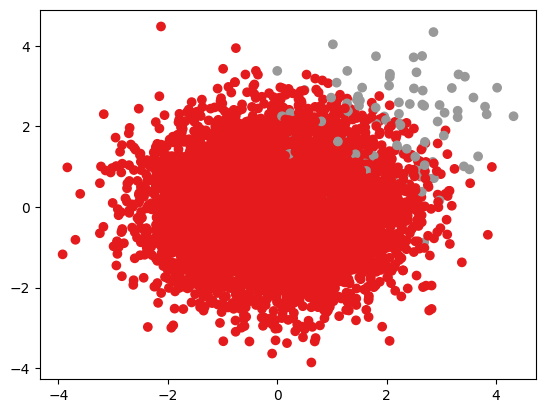

In [ ]:
plt.scatter(df['X1'],df['X2'] ,cmap= 'Set1',c=df['target'].values )

plt.show()

In [6]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split

x1,x2,y1,y2 =train_test_split(df[['X1','X2']],df['target'],test_size = 0.3,random_state = 12)
sampler = RandomUnderSampler(random_state =12)
x1_sample , y1_sample = sampler.fit_resample(x1,y1)

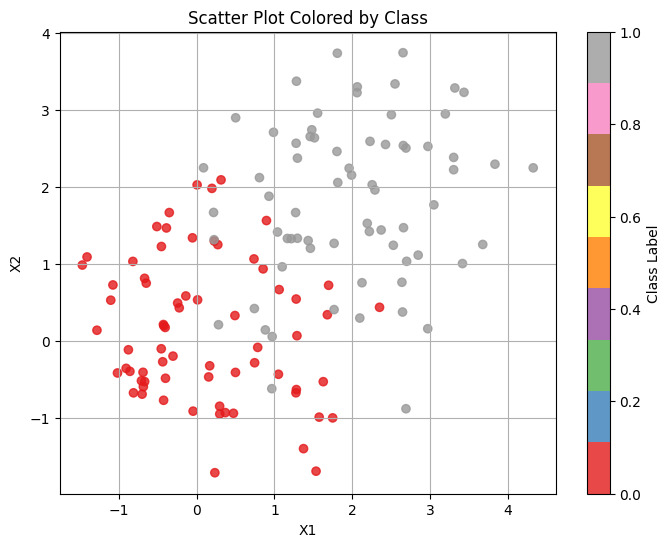

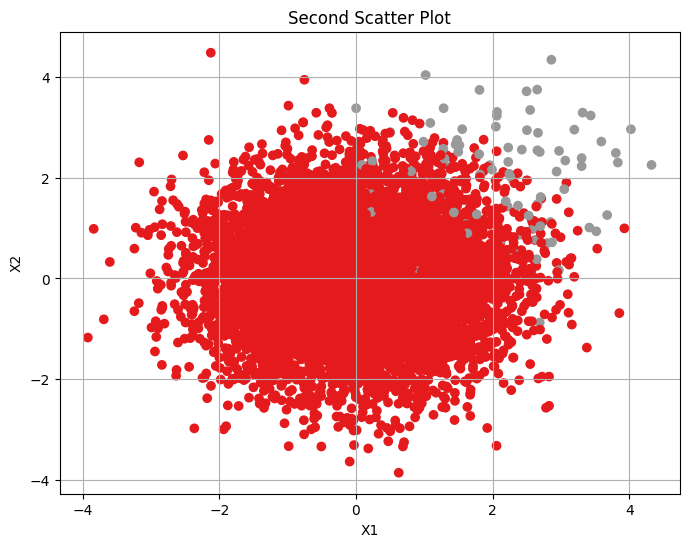

In [ ]:
import matplotlib.pyplot as plt

# First plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(x1_sample['X1'], x1_sample['X2'], c=y1_sample, cmap='Set1', alpha=0.8)
plt.colorbar(scatter, label='Class Label')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Scatter Plot Colored by Class')
plt.grid(True)
plt.show()

# Second plot
plt.figure(figsize=(8, 6))  # Create a new figure for the second plot
plt.scatter(df['X1'], df['X2'], c=df['target'].values, cmap='Set1')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Second Scatter Plot')
plt.grid(True)
plt.show()



# UPSAMPLING AND SMOTE

In [10]:
import matplotlib.pyplot  as plt

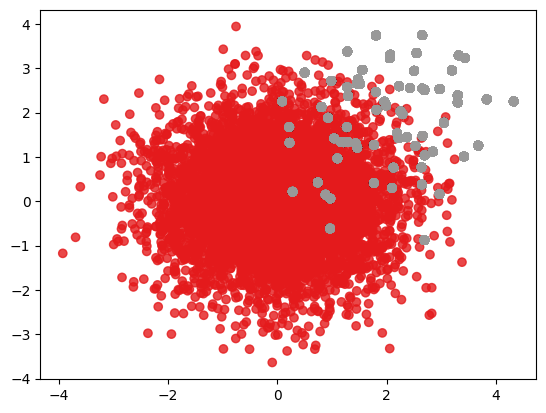

In [12]:
from imblearn.over_sampling import SMOTE, RandomOverSampler
over_sampler = RandomOverSampler(random_state =12)
a, b = over_sampler.fit_resample(x1,y1)
plt.scatter(a['X1'] , a['X2'] , c= b , cmap='Set1', alpha=0.8)

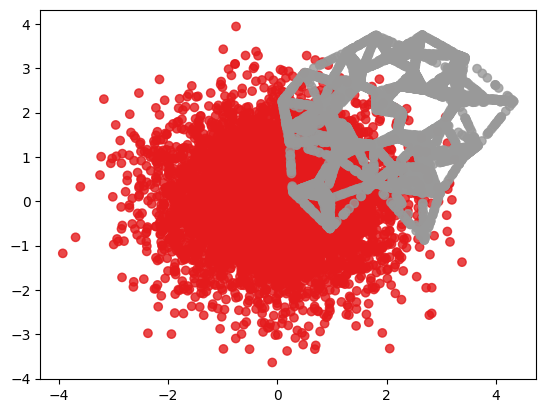

In [14]:
over_sampler = SMOTE(random_state =12)
a, b = over_sampler.fit_resample(x1,y1)
plt.scatter(a['X1'] , a['X2'] , c= b , cmap='Set1', alpha=0.8)

# ENSEMBLE METHOD


In [24]:
from imblearn.ensemble import BalancedRandomForestClassifier
clf = BalancedRandomForestClassifier()
clf.fit(x1,y1)
clf.predict(x2)
clf.predict_proba(x1)[:,1]

array([0.  , 0.01, 0.  , ..., 0.9 , 0.06, 0.  ])